
📂 Membaca: CM_CRJC_20260624_220511.mseed

📂 Membaca: DR_SDD_20260624_220434.mseed

✅ Plot data mentah tersimpan di: /Volumes/Extreme SSD/venezuela_data_earthquake/visualisasi_venezuela/twin_earthquakes_raw.png


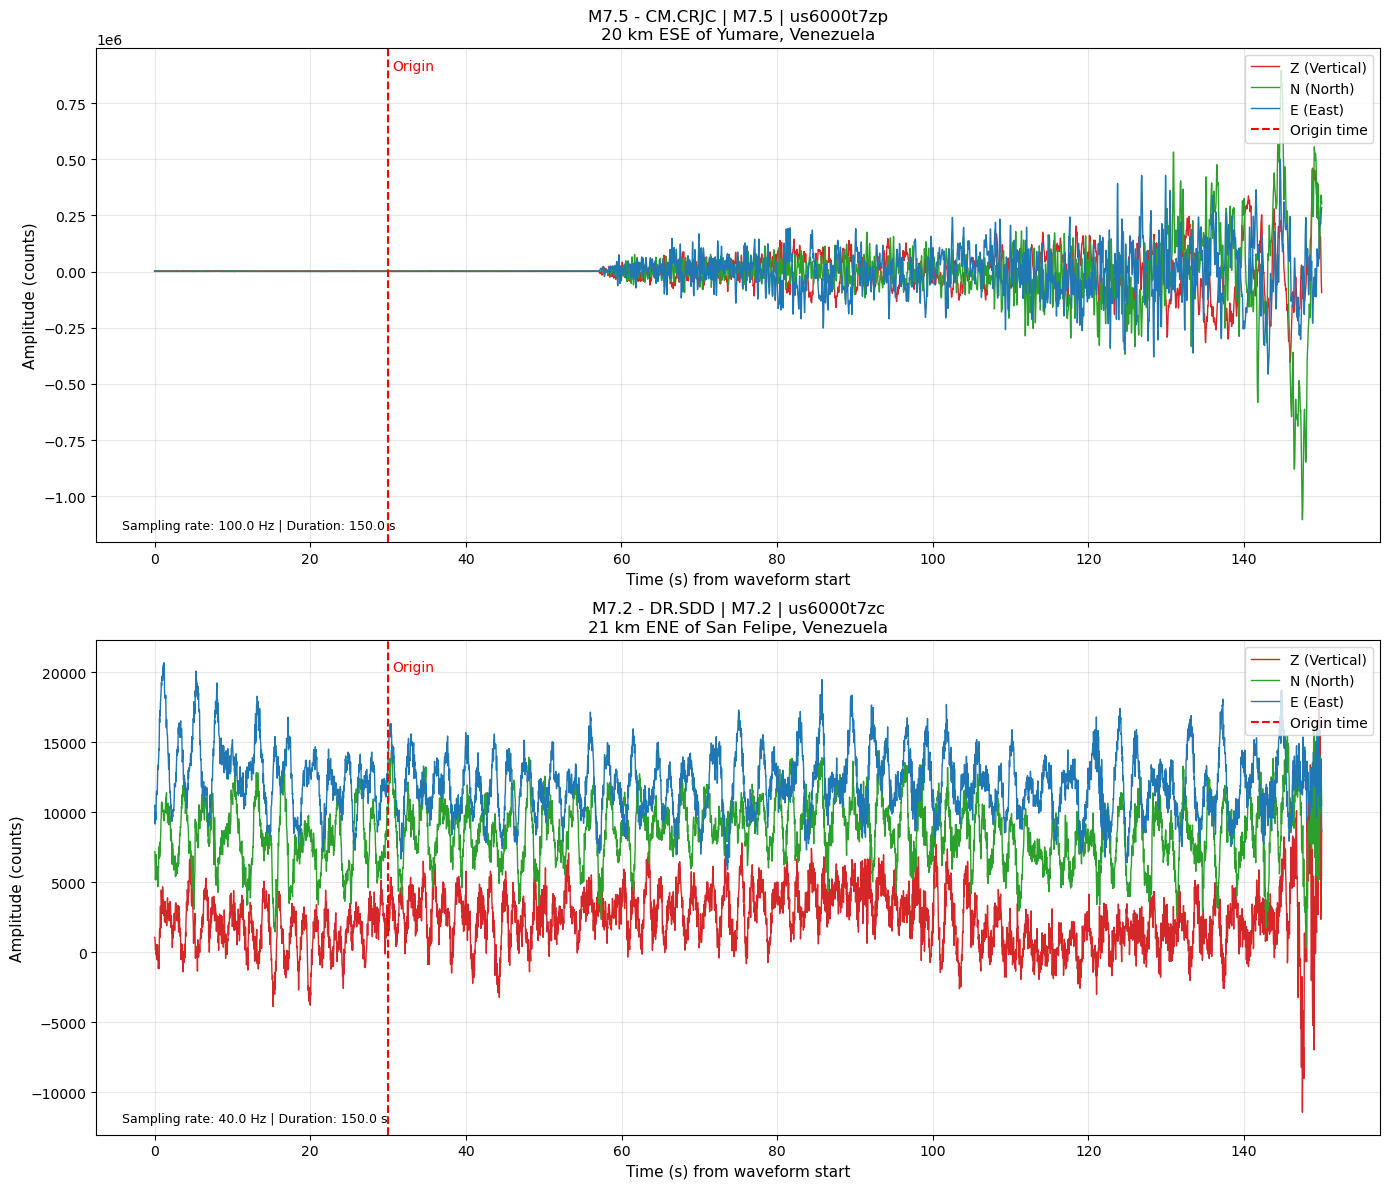


✨ Selesai.


In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VISUALISASI DATA MENTAH (RAW WAVEFORM) UNTUK GEMPA KEMBAR VENEZUELA
- Membaca file .mseed langsung
- Menampilkan sinyal dalam satuan counts
- Tanpa normalisasi
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from obspy import read
from datetime import timezone

# =============================================
# 1. KONFIGURASI PATH
# =============================================
WAVEFORM_DIR = "/Volumes/Extreme SSD/venezuela_data_earthquake/waveform_venezuela_3c_v3"
CATALOG_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/venezuela_earthquake_bench/query_venezuela.csv"
OUTPUT_DIR = "/Volumes/Extreme SSD/venezuela_data_earthquake/visualisasi_venezuela"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_IMAGE = os.path.join(OUTPUT_DIR, "twin_earthquakes_raw.png")

# =============================================
# 2. TARGET EVENT
# =============================================
targets = [
    {"net": "CM", "sta": "CRJC", "ts": "20260624_220511", "mag": "7.5", "label": "M7.5 - CM.CRJC"},
    {"net": "DR", "sta": "SDD", "ts": "20260624_220434", "mag": "7.2", "label": "M7.2 - DR.SDD"}
]

# =============================================
# 3. CARI FILE
# =============================================
files_found = []
for target in targets:
    pattern = f"{target['net']}_{target['sta']}_{target['ts']}"
    for f in os.listdir(WAVEFORM_DIR):
        if f.startswith(pattern) and f.endswith('.mseed') and not f.startswith('._'):
            files_found.append({
                "path": os.path.join(WAVEFORM_DIR, f),
                "net": target['net'],
                "sta": target['sta'],
                "ts": target['ts'],
                "mag": target['mag'],
                "label": target['label'],
                "filename": f
            })
            break

if len(files_found) == 0:
    print("❌ Tidak ada file ditemukan. Periksa WAVEFORM_DIR.")
    exit()

# =============================================
# 4. BACA KATALOG
# =============================================
df_catalog = pd.read_csv(CATALOG_PATH)
df_catalog['time_dt'] = pd.to_datetime(df_catalog['time'], utc=True)

# =============================================
# 5. PLOT
# =============================================
fig, axes = plt.subplots(len(files_found), 1, figsize=(14, 6 * len(files_found)))
if len(files_found) == 1:
    axes = [axes]

for ax, file_info in zip(axes, files_found):
    st = read(file_info['path'])
    print(f"\n📂 Membaca: {file_info['filename']}")
    
    # Ambil komponen Z, N, E
    trace_z = None
    trace_n = None
    trace_e = None
    for tr in st:
        ch = tr.stats.channel
        if ch.endswith('Z'):
            trace_z = tr
        elif ch.endswith('N'):
            trace_n = tr
        elif ch.endswith('E'):
            trace_e = tr
    
    if trace_z is None:
        trace_z = st.select(channel="HHZ")[0] if st.select(channel="HHZ") else st[0]
    
    sr = trace_z.stats.sampling_rate
    duration = len(trace_z.data) / sr
    starttime = trace_z.stats.starttime  # obspy.UTCDateTime
    
    # Cari origin time dari katalog
    ts = file_info['ts']
    origin_dt = pd.Timestamp(f"{ts[:4]}-{ts[4:6]}-{ts[6:8]} {ts[9:11]}:{ts[11:13]}:{ts[13:15]}", tz='UTC')
    mask = (df_catalog['time_dt'] >= origin_dt - pd.Timedelta(seconds=5)) & (df_catalog['time_dt'] <= origin_dt + pd.Timedelta(seconds=5))
    row = df_catalog[mask]
    if not row.empty:
        origin_time = row.iloc[0]['time_dt']  # pd.Timestamp
        mag = row.iloc[0]['mag']
        place = row.iloc[0]['place']
        event_id = row.iloc[0]['id']
    else:
        origin_time = None
        mag = file_info['mag']
        place = "Unknown"
        event_id = "Unknown"
    
    # Plot data mentah
    t = np.arange(len(trace_z.data)) / sr
    ax.plot(t, trace_z.data, label='Z (Vertical)', color='#d62728', linewidth=1.0)
    if trace_n is not None:
        ax.plot(t, trace_n.data, label='N (North)', color='#2ca02c', linewidth=1.0)
    if trace_e is not None:
        ax.plot(t, trace_e.data, label='E (East)', color='#1f77b4', linewidth=1.0)
    
    # Tandai origin time (gunakan timestamp untuk menghitung selisih)
    if origin_time is not None:
        # starttime.timestamp -> float detik sejak epoch (UTC)
        # origin_time.timestamp() -> float detik sejak epoch (UTC)
        origin_seconds = origin_time.timestamp() - starttime.timestamp
        ax.axvline(x=origin_seconds, color='red', linestyle='--', linewidth=1.5, label='Origin time')
        ax.text(origin_seconds + 0.5, ax.get_ylim()[1]*0.9, 'Origin', color='red', fontsize=10)
    
    ax.set_title(f"{file_info['label']} | M{mag} | {event_id}\n{place}", fontsize=12)
    ax.set_xlabel('Time (s) from waveform start', fontsize=11)
    ax.set_ylabel('Amplitude (counts)', fontsize=11)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)
    ax.text(0.02, 0.02, f"Sampling rate: {sr:.1f} Hz | Duration: {duration:.1f} s", 
            transform=ax.transAxes, fontsize=9, verticalalignment='bottom')

plt.tight_layout()
plt.savefig(OUTPUT_IMAGE, dpi=300)
print(f"\n✅ Plot data mentah tersimpan di: {OUTPUT_IMAGE}")
plt.show()
print("\n✨ Selesai.")

In [8]:
import json

JSON_PATH = '/Volumes/Extreme SSD/venezuela_data_earthquake/json_venezuela/extracted_data_3c_venez_v3.json'

with open(JSON_PATH, 'r') as f:
    data = json.load(f)

# Cari key yang mengandung timestamp gempa kembar
keys = list(data.keys())
print(f"Total entri: {len(keys)}")
for k in keys:
    if '20260624' in k:
        print(f"Ditemukan: {k}")

Total entri: 3942
Ditemukan: CM_URI_20260624_222355
Ditemukan: CM_URI_20260624_225400
Ditemukan: CM_URI_20260624_220511
Ditemukan: CM_CRJC_20260624_222355
Ditemukan: CM_CRJC_20260624_220511
Ditemukan: CM_CRJC_20260624_225400
Ditemukan: CM_OCA_20260624_222355
Ditemukan: CM_OCA_20260624_220511
Ditemukan: CM_OCA_20260624_225400
Ditemukan: DR_SDD_20260624_222355
Ditemukan: DR_SDD_20260624_220511
Ditemukan: DR_SDD_20260624_225400
Ditemukan: GT_LPAZ_20260624_222355
Ditemukan: GT_LPAZ_20260624_220511
Ditemukan: GT_LPAZ_20260624_225400
Ditemukan: GE_BOAB_20260624_222355
Ditemukan: G_FDFM_20260624_222355
Ditemukan: GE_BOAB_20260624_220511
Ditemukan: GE_BOAB_20260624_225400
Ditemukan: G_FDFM_20260624_220511
Ditemukan: CM_URI_20260624_220434
Ditemukan: G_FDFM_20260624_225400
Ditemukan: CM_CRJC_20260624_220434
Ditemukan: CM_OCA_20260624_220434
Ditemukan: DR_SDD_20260624_220434
Ditemukan: GT_LPAZ_20260624_220434
Ditemukan: GE_BOAB_20260624_220434
Ditemukan: G_FDFM_20260624_220434


In [9]:
ls -la "/Volumes/Extreme SSD/venezuela_data_earthquake/waveform_venezuela_3c_v3/" | grep 20260624

-rwx------  1 verykurniabakti  staff     4096 Jul 15 15:04 ._CM_CRJC_20260624_220434.mseed*
-rwx------  1 verykurniabakti  staff     4096 Jul 15 15:00 ._CM_CRJC_20260624_220511.mseed*
-rwx------  1 verykurniabakti  staff     4096 Jul 15 15:00 ._CM_CRJC_20260624_222355.mseed*
-rwx------  1 verykurniabakti  staff     4096 Jul 15 15:00 ._CM_CRJC_20260624_225400.mseed*
-rwx------  1 verykurniabakti  staff     4096 Jul 15 15:04 ._CM_OCA_20260624_220434.mseed*
-rwx------  1 verykurniabakti  staff     4096 Jul 15 15:00 ._CM_OCA_20260624_220511.mseed*
-rwx------  1 verykurniabakti  staff     4096 Jul 15 15:00 ._CM_OCA_20260624_222355.mseed*
-rwx------  1 verykurniabakti  staff     4096 Jul 15 15:00 ._CM_OCA_20260624_225400.mseed*
-rwx------  1 verykurniabakti  staff     4096 Jul 15 15:04 ._CM_URI_20260624_220434.mseed*
-rwx------  1 verykurniabakti  staff     4096 Jul 15 15:00 ._CM_URI_20260624_220511.mseed*
-rwx------  1 verykurniabakti  staff     4096 Jul 15 14:59 ._CM_URI_20260624_222355.ms

In [10]:
import os
from pathlib import Path

WAVEFORM_DIR = "/Volumes/Extreme SSD/venezuela_data_earthquake/waveform_venezuela_3c_v3"

wave_dir = Path(WAVEFORM_DIR)
files = list(wave_dir.glob("*20260624*.mseed"))
print(f"Ditemukan {len(files)} file untuk 24 Juni 2026:")
for f in files[:10]:
    print(f"  {f.name}")

Ditemukan 56 file untuk 24 Juni 2026:
  CM_URI_20260624_222355.mseed
  ._CM_URI_20260624_222355.mseed
  CM_URI_20260624_225400.mseed
  ._CM_URI_20260624_225400.mseed
  CM_URI_20260624_220511.mseed
  ._CM_URI_20260624_220511.mseed
  CM_CRJC_20260624_222355.mseed
  ._CM_CRJC_20260624_222355.mseed
  CM_CRJC_20260624_220511.mseed
  ._CM_CRJC_20260624_220511.mseed


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


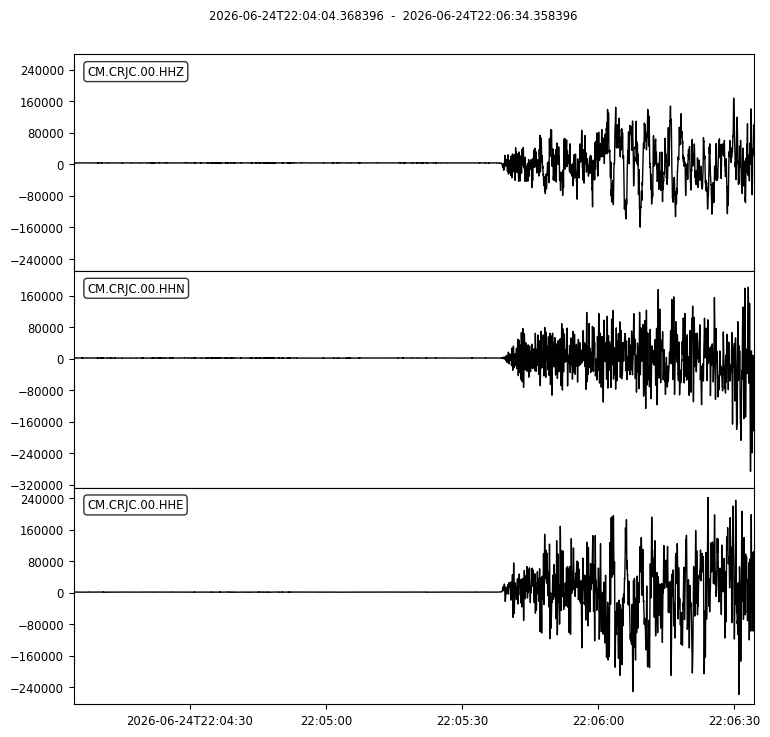

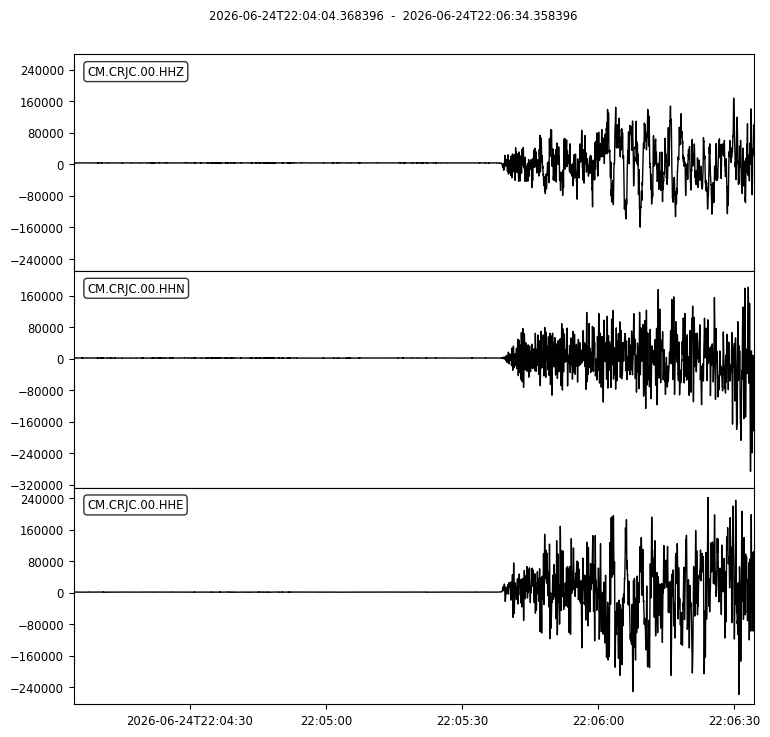

In [11]:
from obspy import read
import numpy as np

file_path = "/Volumes/Extreme SSD/venezuela_data_earthquake/waveform_venezuela_3c_v3/CM_CRJC_20260624_220434.mseed"
st = read(file_path)
st.plot()  # lihat waveform mentah

In [6]:
import json
import numpy as np

json_path = '/Volumes/Extreme SSD/venezuela_data_earthquake/json_venezuela/extracted_data_3c_venez_v3.json'
with open(json_path, 'r') as f:
    data = json.load(f)

key = 'CM_CRJC_20260624_220434'
entry = data.get(key)
if entry:
    Z = np.array(entry['Z'])
    N = np.array(entry['N'])
    E = np.array(entry['E'])
    print(f"Z: min={Z.min():.3f}, max={Z.max():.3f}, mean={Z.mean():.3f}, std={Z.std():.3f}")
    print(f"N: min={N.min():.3f}, max={N.max():.3f}, mean={N.mean():.3f}, std={N.std():.3f}")
    print(f"E: min={E.min():.3f}, max={E.max():.3f}, mean={E.mean():.3f}, std={E.std():.3f}")
    print(f"p_arrival: {entry['metadata']['p_arrival']}")
else:
    print(f"Key {key} tidak ditemukan.")

Z: min=-0.977, max=0.626, mean=-0.031, std=0.298
N: min=-1.429, max=0.538, mean=-0.364, std=0.376
E: min=-0.448, max=0.926, mean=0.287, std=0.283
p_arrival: 2026-06-24T22:05:39.208396Z


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


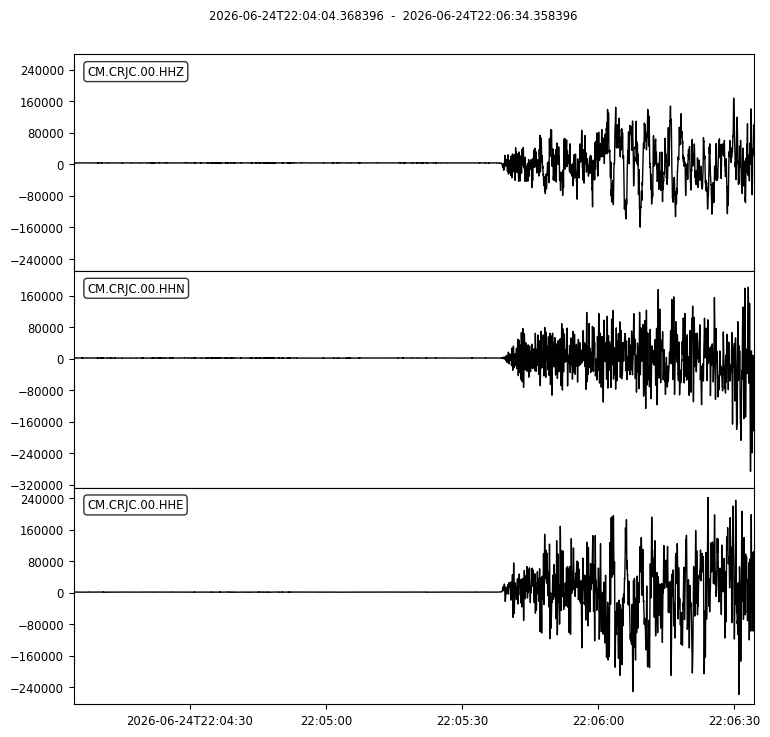

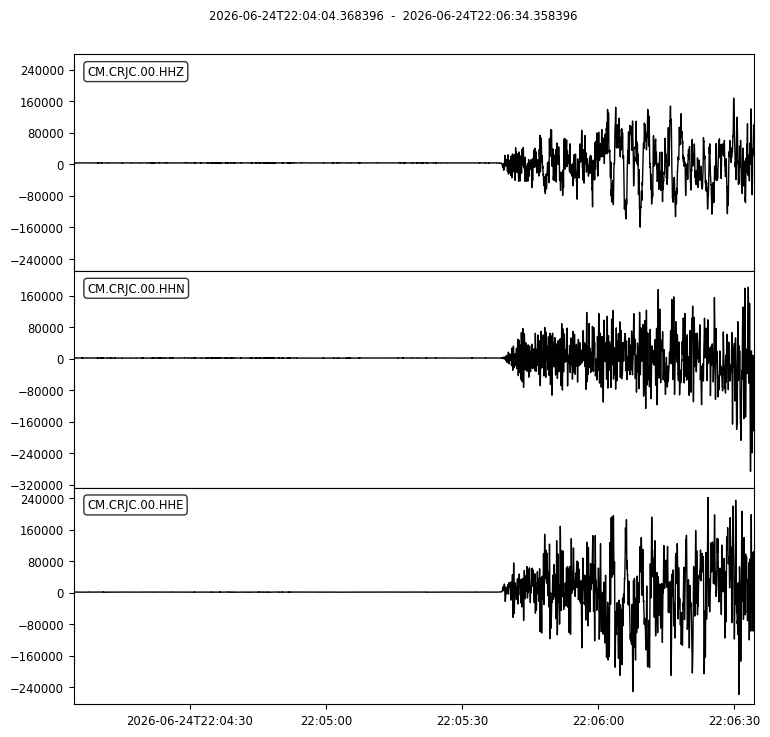

In [7]:
from obspy import read
import matplotlib.pyplot as plt

file_path = "/Volumes/Extreme SSD/venezuela_data_earthquake/waveform_venezuela_3c_v3/CM_CRJC_20260624_220434.mseed"
st = read(file_path)
st.plot()  # akan menampilkan waveform

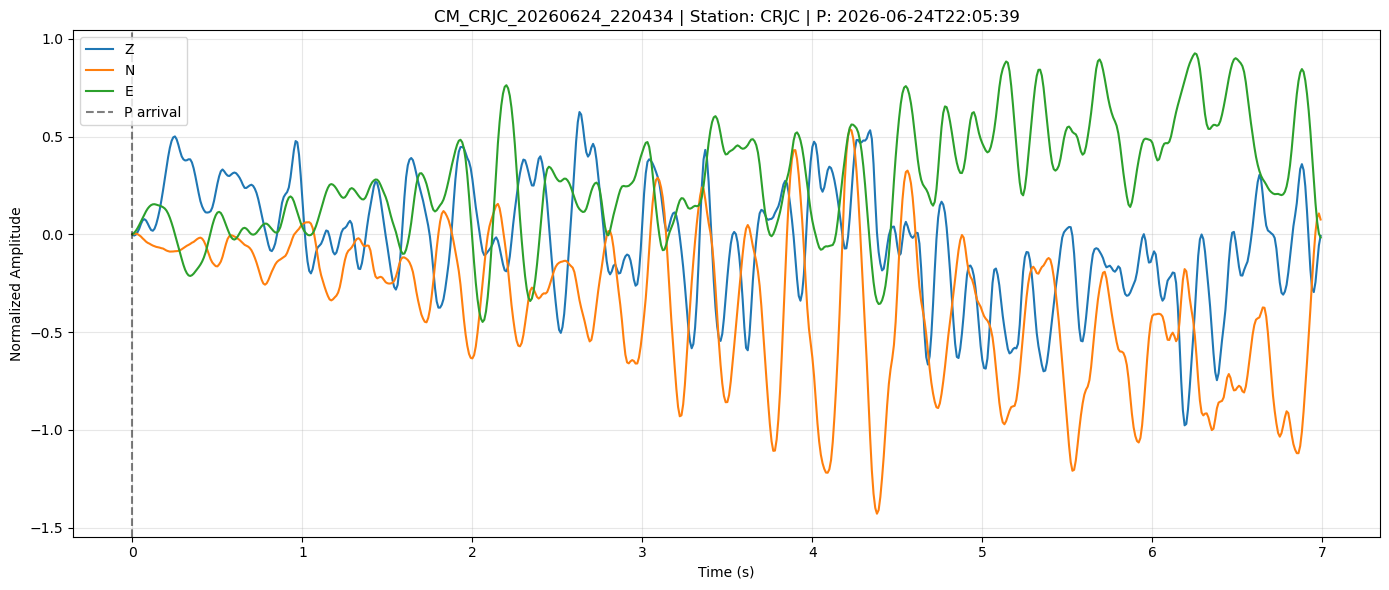

In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np

json_path = '/Volumes/Extreme SSD/venezuela_data_earthquake/json_venezuela/extracted_data_3c_venez_v3.json'
with open(json_path, 'r') as f:
    data = json.load(f)

key = 'CM_CRJC_20260624_220434'
entry = data[key]

Z = np.array(entry['Z'])
N = np.array(entry['N'])
E = np.array(entry['E'])
t = np.arange(len(Z)) / 100.0  # 100 Hz

plt.figure(figsize=(14, 6))
plt.plot(t, Z, label='Z', linewidth=1.5)
plt.plot(t, N, label='N', linewidth=1.5)
plt.plot(t, E, label='E', linewidth=1.5)
plt.axvline(0, color='black', linestyle='--', alpha=0.5, label='P arrival')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title(f'{key} | Station: {entry["metadata"]["station"]} | P: {entry["metadata"]["p_arrival"][:19]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

🔧 Memuat model dan embedding...


2026-07-16 06:44:24.126762: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-16 06:44:24.126791: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-16 06:44:24.126796: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-16 06:44:24.126819: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-16 06:44:24.126831: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


📂 Memuat JSON: /Volumes/Extreme SSD/venezuela_data_earthquake/json_venezuela/extracted_data_3c_venez_v3.json
✅ Total entri di JSON: 3942
✅ Ditemukan: CM_CRJC_20260624_220434
✅ Ditemukan: CM_CRJC_20260624_220511

🔍 Memproses: CM_CRJC_20260624_220434
   P_s (prob. earthquake): 1.0000
   P_n (prob. noise)     : 0.0000
   Prediksi              : LE
   Embedding sinyal (E,N,Z): [2.0544763 1.2527342 1.6801665]

🔍 Memproses: CM_CRJC_20260624_220511
   P_s (prob. earthquake): 1.0000
   P_n (prob. noise)     : 0.0000
   Prediksi              : LE
   Embedding sinyal (E,N,Z): [2.0544763 1.2527342 1.6801665]

📊 Membuat visualisasi...


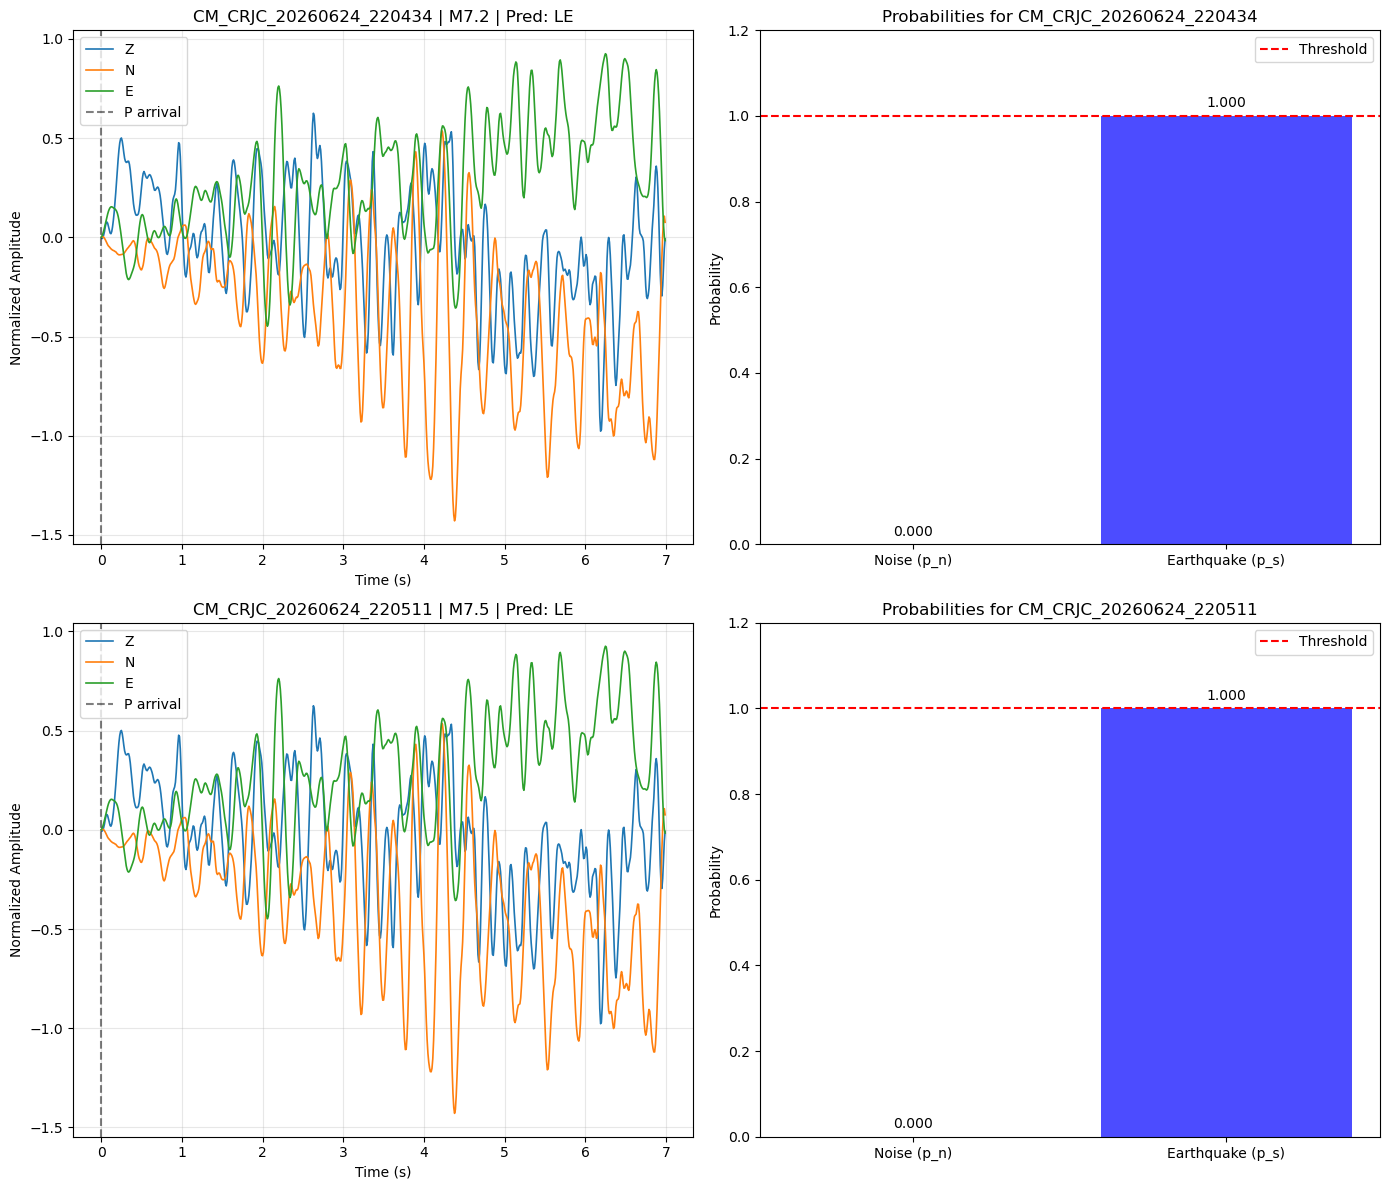


✅ Visualisasi tersimpan di: /Volumes/Extreme SSD/venezuela_data_earthquake/test_twin_events/twin_earthquakes_inference.png
✅ Hasil inferensi disimpan di: /Volumes/Extreme SSD/venezuela_data_earthquake/test_twin_events/inference_results.json

✨ Selesai.


In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
UJI MCU-QUAKE PADA GEMPA KEMBAR VENEZUELA (24 JUNI 2026)
- Menggunakan model pre-trained MCU-5-20 dan embedding UUSS.
- Menampilkan prediksi (NO/LE), embedding value, dan probabilitas.
- Visualisasi sinyal 3C dan embedding.
"""

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from Library import utils, dataset

# =============================================
# 1. KONFIGURASI
# =============================================
# Path JSON 3C Venezuela (yang sudah berisi gempa kembar)
JSON_PATH = "/Volumes/Extreme SSD/venezuela_data_earthquake/json_venezuela/extracted_data_3c_venez_v3.json"

# Event yang akan diuji (gempa kembar)
# Format key: NET_STA_YYYYMMDD_HHMMSS
# M7.2 terjadi 22:04:34, M7.5 terjadi 22:05:11
TARGET_KEYS = [
    "CM_CRJC_20260624_220434",  # M7.2
    "CM_CRJC_20260624_220511"   # M7.5
]

# Path model dan embedding (sama seperti skrip evaluasi)
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")

# Parameter input
INPUT_WIN = 7
SAMPLING_RATE = 100
NUM_POINTS = int(INPUT_WIN * SAMPLING_RATE)

# Threshold untuk klasifikasi (sesuai kode evaluasi)
THRESHOLD = 1.0

# Output folder
OUTPUT_DIR = "/Volumes/Extreme SSD/venezuela_data_earthquake/test_twin_events"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =============================================
# 2. LOAD MODEL & EMBEDDING
# =============================================
print("🔧 Memuat model dan embedding...")
embedding_model = keras.models.load_model(filepath=MODEL_PATH)
embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")

# Estimasi KDE untuk embedding 3C
embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

# =============================================
# 3. LOAD JSON & AMBIL EVENT TARGET
# =============================================
print(f"📂 Memuat JSON: {JSON_PATH}")
with open(JSON_PATH, 'r') as f:
    data_all = json.load(f)

print(f"✅ Total entri di JSON: {len(data_all)}")

# Ambil data untuk target keys
event_data = {}
for key in TARGET_KEYS:
    if key in data_all:
        event_data[key] = data_all[key]
        print(f"✅ Ditemukan: {key}")
    else:
        print(f"❌ Key tidak ditemukan: {key}")

if not event_data:
    print("⚠️ Tidak ada event yang ditemukan. Periksa key atau JSON.")
    exit()

# =============================================
# 4. FUNGSI INFERENSI UNTUK SATU EVENT
# =============================================
def infer_event(record):
    """
    Lakukan inferensi untuk satu event (sudah berisi Z, N, E, noise).
    Kembalikan: embedding_signal, embedding_noise, p_s, p_n, pred_label
    """
    # Ambil sinyal dan noise (3 komponen)
    Z_s = np.array(record['Z'][:NUM_POINTS])
    N_s = np.array(record['N'][:NUM_POINTS])
    E_s = np.array(record['E'][:NUM_POINTS])
    
    Z_n = np.array(record['Z_noise'][-NUM_POINTS:])
    N_n = np.array(record['N_noise'][-NUM_POINTS:])
    E_n = np.array(record['E_noise'][-NUM_POINTS:])
    
    # Dapatkan latent codes (embedding) untuk masing-masing komponen
    # Fungsi latent_codes_1D mengharapkan array 1D dan model, mengembalikan embedding value (skalar)
    emb_Zs = utils.latent_codes_1D(Z_s, embedding_model)
    emb_Ns = utils.latent_codes_1D(N_s, embedding_model)
    emb_Es = utils.latent_codes_1D(E_s, embedding_model)
    
    emb_Zn = utils.latent_codes_1D(Z_n, embedding_model)
    emb_Nn = utils.latent_codes_1D(N_n, embedding_model)
    emb_En = utils.latent_codes_1D(E_n, embedding_model)
    
    # Susun embedding 3C untuk sinyal dan noise (urutan: E, N, Z sesuai fungsi infer_3C_PDFs)
    emb_s_3c = np.array([emb_Es, emb_Ns, emb_Zs]).reshape(1, -1)
    emb_n_3c = np.array([emb_En, emb_Nn, emb_Zn]).reshape(1, -1)
    
    # Inferensi KDE
    p_s, _, _ = utils.infer_3C_PDFs(emb_s_3c, embeddings_3C_PDFs, "Kernel")
    p_n, _, _ = utils.infer_3C_PDFs(emb_n_3c, embeddings_3C_PDFs, "Kernel")
    
    # Prediksi (threshold = 1.0, seperti di kode evaluasi)
    pred_label = "LE" if p_s >= THRESHOLD else "NO"
    
    return {
        'emb_signal': emb_s_3c.flatten(),  # [E, N, Z]
        'emb_noise': emb_n_3c.flatten(),
        'p_s': p_s,
        'p_n': p_n,
        'pred_label': pred_label,
        'Z_s': Z_s, 'N_s': N_s, 'E_s': E_s,
        'Z_n': Z_n, 'N_n': N_n, 'E_n': E_n
    }

# =============================================
# 5. PROSES SEMUA EVENT TARGET
# =============================================
results = {}
for key, record in event_data.items():
    print(f"\n🔍 Memproses: {key}")
    try:
        res = infer_event(record)
        results[key] = res
        # Tampilkan hasil
        print(f"   P_s (prob. earthquake): {res['p_s']:.4f}")
        print(f"   P_n (prob. noise)     : {res['p_n']:.4f}")
        print(f"   Prediksi              : {res['pred_label']}")
        print(f"   Embedding sinyal (E,N,Z): {res['emb_signal']}")
    except Exception as e:
        print(f"   ❌ Error: {e}")

# =============================================
# 6. VISUALISASI
# =============================================
print("\n📊 Membuat visualisasi...")

fig, axes = plt.subplots(len(results), 2, figsize=(14, 6*len(results)))
if len(results) == 1:
    axes = [axes]

for idx, (key, res) in enumerate(results.items()):
    # Plot sinyal 3C
    ax1 = axes[idx, 0]
    t = np.arange(NUM_POINTS) / SAMPLING_RATE
    ax1.plot(t, res['Z_s'], label='Z', linewidth=1.2)
    ax1.plot(t, res['N_s'], label='N', linewidth=1.2)
    ax1.plot(t, res['E_s'], label='E', linewidth=1.2)
    ax1.axvline(0, color='black', linestyle='--', alpha=0.5, label='P arrival')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Normalized Amplitude')
    # Tentukan magnitudo dari key (cari di katalog atau hardcode)
    if "220434" in key:
        mag = "7.2"
    elif "220511" in key:
        mag = "7.5"
    else:
        mag = "?"
    ax1.set_title(f'{key} | M{mag} | Pred: {res["pred_label"]}')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Plot nilai probabilitas sebagai bar
    ax2 = axes[idx, 1]
    labels = ['Noise (p_n)', 'Earthquake (p_s)']
    probs = [res['p_n'], res['p_s']]
    colors = ['grey', 'blue']
    bars = ax2.bar(labels, probs, color=colors, alpha=0.7)
    ax2.axhline(THRESHOLD, color='red', linestyle='--', label='Threshold')
    ax2.set_ylim(0, max(1.2, max(probs)*1.2))
    ax2.set_ylabel('Probability')
    ax2.set_title(f'Probabilities for {key}')
    for bar, val in zip(bars, probs):
        ax2.text(bar.get_x() + bar.get_width()/2., val + 0.02, f'{val:.3f}', ha='center')
    ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'twin_earthquakes_inference.png'), dpi=300)
plt.show()

print(f"\n✅ Visualisasi tersimpan di: {OUTPUT_DIR}/twin_earthquakes_inference.png")

# =============================================
# 7. SIMPAN HASIL INFERENSI KE JSON
# =============================================
output_json = os.path.join(OUTPUT_DIR, 'inference_results.json')
with open(output_json, 'w') as f:
    json.dump(results, f, indent=2, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
print(f"✅ Hasil inferensi disimpan di: {output_json}")

print("\n✨ Selesai.")

In [10]:
import json
import numpy as np

json_path = '/Volumes/Extreme SSD/venezuela_data_earthquake/json_venezuela/extracted_data_3c_venez_v3.json'
with open(json_path, 'r') as f:
    data = json.load(f)

key = 'CM_CRJC_20260624_220511'
entry = data[key]
Z = np.array(entry['Z'])
print(f"Z: min={Z.min():.3f}, max={Z.max():.3f}, mean={Z.mean():.3f}, std={Z.std():.3f}")
print(f"Z[:10]: {Z[:10]}")

Z: min=-0.977, max=0.626, mean=-0.031, std=0.298
Z[:10]: [ 0.         -0.00644555 -0.00179949  0.01112757  0.02868871  0.05298159
  0.07136535  0.07765664  0.07088204  0.0549764 ]


In [12]:
import json
import numpy as np
from tensorflow import keras

# =============================================
# KONFIGURASI
# =============================================
JSON_PATH = "/Volumes/Extreme SSD/venezuela_data_earthquake/json_venezuela/extracted_data_3c_venez_v3.json"
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"

# Event target (gempa kembar)
TARGET_KEYS = [
    "CM_CRJC_20260624_220434",  # M7.2
    "CM_CRJC_20260624_220511"   # M7.5
]

# =============================================
# 1. LOAD MODEL
# =============================================
print("🔧 Memuat model...")
model = keras.models.load_model(MODEL_PATH)
print("✅ Model loaded.")

# =============================================
# 2. LOAD JSON
# =============================================
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

# =============================================
# 3. INFERENSI UNTUK SETIAP EVENT
# =============================================
for key in TARGET_KEYS:
    if key not in data:
        print(f"❌ Key {key} tidak ditemukan di JSON.")
        continue
    
    entry = data[key]
    # Ambil sinyal Z (700 sampel)
    Z_s = np.array(entry['Z'][:700]).reshape(1, -1, 1)  # shape (1, 700, 1)
    
    # Dapatkan embedding (output model)
    # MCU-Quake 1C menghasilkan embedding skalar (bisa dicek shape output)
    embedding = model.predict(Z_s, verbose=0)[0][0]  # asumsi output (batch, 1)
    
    # Tentukan prediksi berdasarkan threshold (misal > 0)
    pred = "LE (Earthquake)" if embedding > 0 else "NO (Noise)"
    
    print(f"\n🔍 Event: {key}")
    print(f"   Embedding value: {embedding:.4f}")
    print(f"   Prediksi: {pred}")
    print(f"   Referensi: Earthquake ≈ +1.01, Noise ≈ -5.01")

🔧 Memuat model...


2026-07-16 07:06:36.961079: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-16 07:06:36.961109: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-16 07:06:36.961114: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-16 07:06:36.961136: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-16 07:06:36.961147: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✅ Model loaded.

🔍 Event: CM_CRJC_20260624_220434
   Embedding value: 17.3288
   Prediksi: LE (Earthquake)
   Referensi: Earthquake ≈ +1.01, Noise ≈ -5.01

🔍 Event: CM_CRJC_20260624_220511
   Embedding value: 17.3288
   Prediksi: LE (Earthquake)
   Referensi: Earthquake ≈ +1.01, Noise ≈ -5.01


2026-07-16 07:06:41.365466: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


🔧 Memuat model...
✅ Model loaded.

🔍 Event: CM_CRJC_20260624_220434
   Embedding value: 17.3288
   Prediksi: LE (Earthquake)
   Referensi: Earthquake ≈ +1.01, Noise ≈ -5.01

🔍 Event: CM_CRJC_20260624_220511
   Embedding value: 17.3288
   Prediksi: LE (Earthquake)
   Referensi: Earthquake ≈ +1.01, Noise ≈ -5.01

📊 Membuat plot sinyal 3C...


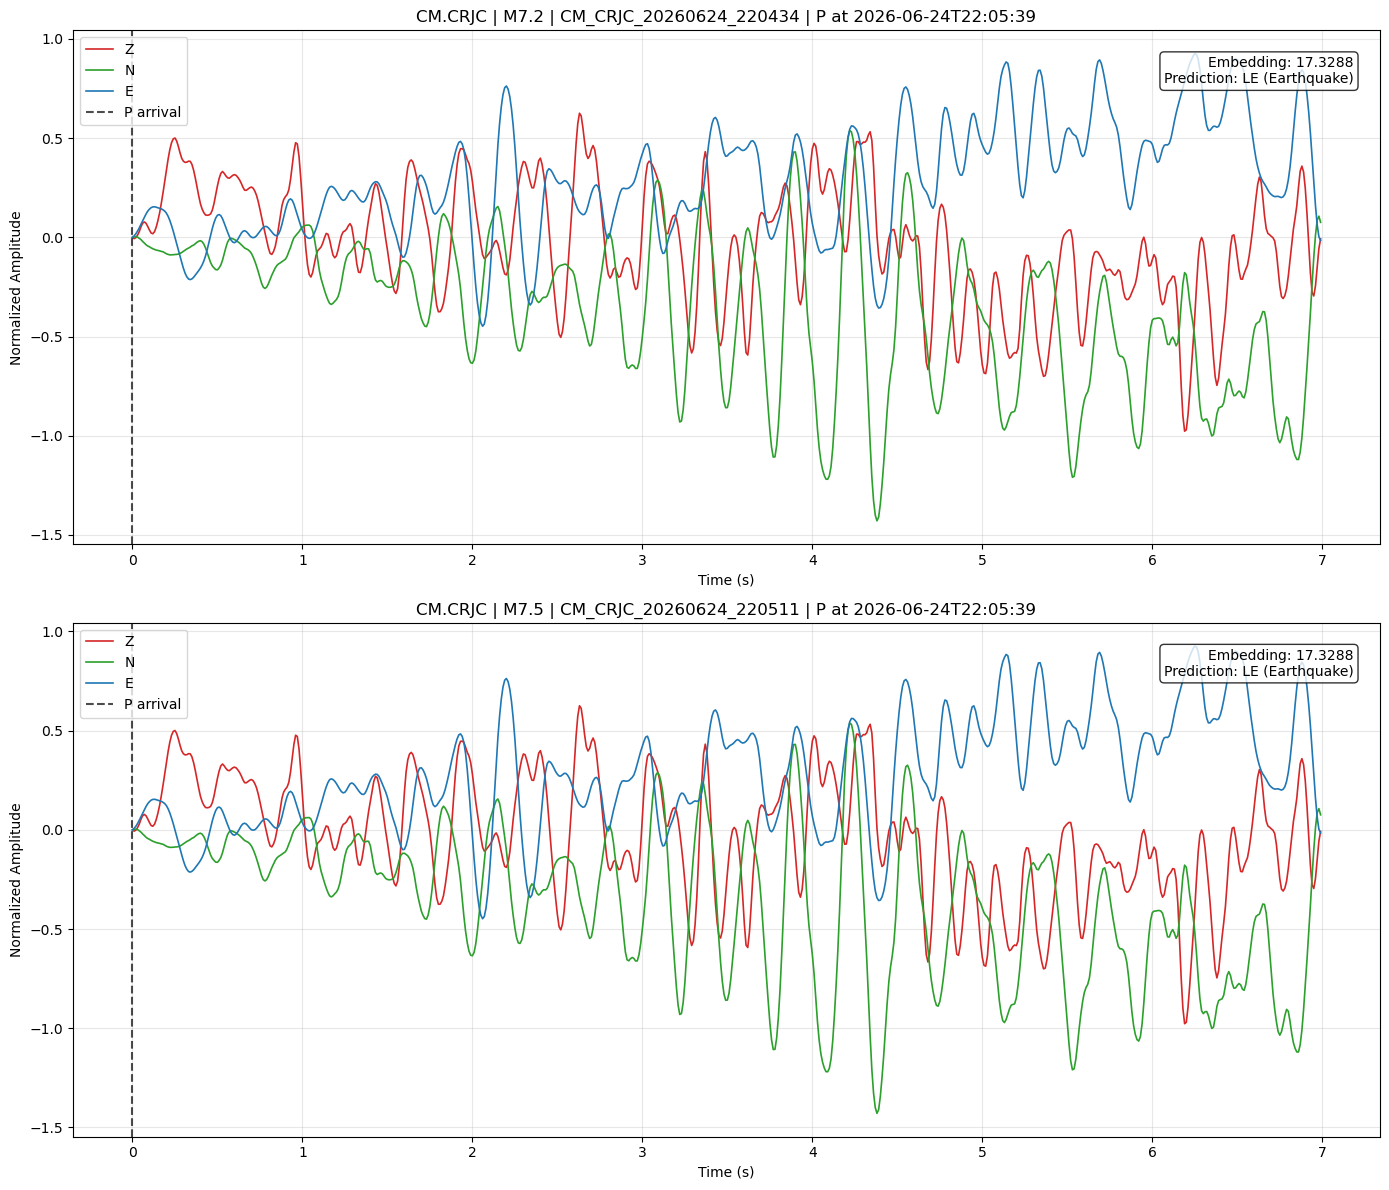

✅ Sinyal plot tersimpan di: /Volumes/Extreme SSD/venezuela_data_earthquake/visualisasi_venezuela/twin_signals_with_prediction.png

📊 Membuat plot distribusi embedding...


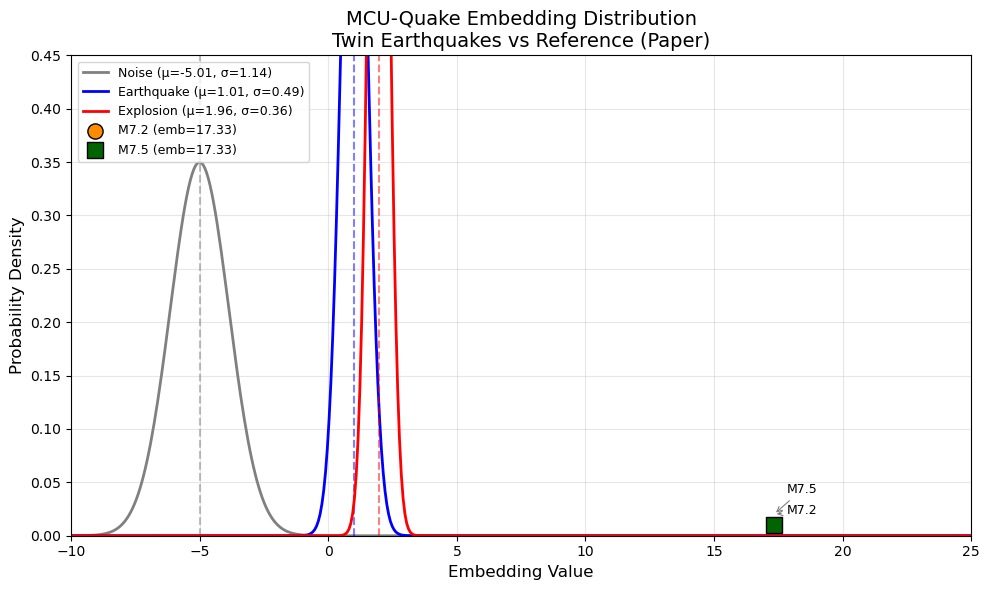

✅ Embedding distribution tersimpan di: /Volumes/Extreme SSD/venezuela_data_earthquake/visualisasi_venezuela/twin_embedding_distribution.png

✨ Selesai. Semua visualisasi tersimpan di: /Volumes/Extreme SSD/venezuela_data_earthquake/visualisasi_venezuela


In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from scipy.stats import norm
import os

# =============================================
# KONFIGURASI
# =============================================
JSON_PATH = "/Volumes/Extreme SSD/venezuela_data_earthquake/json_venezuela/extracted_data_3c_venez_v3.json"
MODEL_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"

# Event target (gempa kembar)
TARGET_KEYS = [
    "CM_CRJC_20260624_220434",  # M7.2
    "CM_CRJC_20260624_220511"   # M7.5
]

# Referensi embedding dari paper MCU-Quake (Fig. 4a)
REFERENCE = {
    "Noise": {"mean": -5.01, "std": 1.14, "color": "grey"},
    "Earthquake": {"mean": 1.01, "std": 0.49, "color": "blue"},
    "Explosion": {"mean": 1.96, "std": 0.36, "color": "red"}
}

# Output folder
OUTPUT_DIR = "/Volumes/Extreme SSD/venezuela_data_earthquake/visualisasi_venezuela"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =============================================
# 1. LOAD MODEL
# =============================================
print("🔧 Memuat model...")
model = keras.models.load_model(MODEL_PATH)
print("✅ Model loaded.")

# =============================================
# 2. LOAD JSON
# =============================================
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

# =============================================
# 3. INFERENSI UNTUK SETIAP EVENT & KUMPULKAN HASIL
# =============================================
results = []
for key in TARGET_KEYS:
    if key not in data:
        print(f"❌ Key {key} tidak ditemukan di JSON.")
        continue
    
    entry = data[key]
    # Ambil sinyal Z, N, E untuk visualisasi
    Z_s = np.array(entry['Z'][:700])
    N_s = np.array(entry['N'][:700]) if 'N' in entry and entry['N'] is not None else None
    E_s = np.array(entry['E'][:700]) if 'E' in entry and entry['E'] is not None else None
    
    # Ambil metadata
    meta = entry['metadata']
    net = meta['network']
    sta = meta['station']
    p_time = meta['p_arrival']
    
    # Inferensi (1C: hanya Z)
    Z_input = Z_s.reshape(1, -1, 1)
    embedding = model.predict(Z_input, verbose=0)[0][0]
    pred = "LE (Earthquake)" if embedding > 0 else "NO (Noise)"
    
    results.append({
        'key': key,
        'net': net,
        'sta': sta,
        'p_time': p_time,
        'embedding': embedding,
        'pred': pred,
        'Z': Z_s,
        'N': N_s,
        'E': E_s,
        'mag': "7.2" if "220434" in key else "7.5"
    })
    
    print(f"\n🔍 Event: {key}")
    print(f"   Embedding value: {embedding:.4f}")
    print(f"   Prediksi: {pred}")
    print(f"   Referensi: Earthquake ≈ +1.01, Noise ≈ -5.01")

# =============================================
# 4. VISUALISASI 1: Sinyal 3C dengan Prediksi
# =============================================
print("\n📊 Membuat plot sinyal 3C...")
fig1, axes = plt.subplots(len(results), 1, figsize=(14, 6 * len(results)))
if len(results) == 1:
    axes = [axes]

for ax, res in zip(axes, results):
    t = np.arange(len(res['Z'])) / 100.0  # 100 Hz
    ax.plot(t, res['Z'], label='Z', color='#d62728', linewidth=1.2)
    if res['N'] is not None:
        ax.plot(t, res['N'], label='N', color='#2ca02c', linewidth=1.2)
    if res['E'] is not None:
        ax.plot(t, res['E'], label='E', color='#1f77b4', linewidth=1.2)
    ax.axvline(0, color='black', linestyle='--', alpha=0.7, label='P arrival')
    
    # Tambahkan anotasi prediksi
    info_text = f"Embedding: {res['embedding']:.4f}\nPrediction: {res['pred']}"
    ax.text(0.98, 0.95, info_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f"{res['net']}.{res['sta']} | M{res['mag']} | {res['key']} | P at {res['p_time'][:19]}", fontsize=12)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized Amplitude')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'twin_signals_with_prediction.png'), dpi=300)
plt.show()
print(f"✅ Sinyal plot tersimpan di: {OUTPUT_DIR}/twin_signals_with_prediction.png")

# =============================================
# 5. VISUALISASI 2: Embedding vs Referensi
# =============================================
print("\n📊 Membuat plot distribusi embedding...")
fig2, ax2 = plt.subplots(figsize=(10, 6))

# Plot kurva Gaussian referensi
x = np.linspace(-10, 25, 500)
for cls, params in REFERENCE.items():
    y = norm.pdf(x, params['mean'], params['std'])
    ax2.plot(x, y, label=f"{cls} (μ={params['mean']}, σ={params['std']})", 
             color=params['color'], linewidth=2)
    ax2.axvline(params['mean'], color=params['color'], linestyle='--', alpha=0.5)

# Plot embedding hasil inferensi
colors = ['darkorange', 'darkgreen']
markers = ['o', 's']
for i, res in enumerate(results):
    emb = res['embedding']
    ax2.scatter(emb, 0.01, color=colors[i % len(colors)], marker=markers[i % len(markers)], 
                s=120, edgecolors='black', zorder=5, 
                label=f"M{res['mag']} (emb={emb:.2f})")
    ax2.annotate(f"M{res['mag']}", xy=(emb, 0.02), xytext=(emb+0.5, 0.02+0.02*i),
                 arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
                 fontsize=9, ha='left')

ax2.set_xlabel('Embedding Value', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.set_title('MCU-Quake Embedding Distribution\nTwin Earthquakes vs Reference (Paper)', fontsize=14)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_xlim(-10, 25)
ax2.set_ylim(0, 0.45)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'twin_embedding_distribution.png'), dpi=300)
plt.show()
print(f"✅ Embedding distribution tersimpan di: {OUTPUT_DIR}/twin_embedding_distribution.png")

print("\n✨ Selesai. Semua visualisasi tersimpan di:", OUTPUT_DIR)

📂 Membaca katalog...
✅ 745 event di katalog.
📂 Membaca JSON 3C...
✅ 3942 entri di JSON 3C.
📍 45 stasiun unik ditemukan di JSON.
   Stasiun: ['CM.CRJC', 'CM.HEL', 'CM.OCA', 'CM.RUS', 'CM.SJC', 'CM.SMAR', 'CM.URI', 'CU.ANWB', 'CU.BBGH', 'CU.BCIP', 'CU.GRGR', 'CU.MTDJ', 'CU.SDDR', 'CU.TGUH', 'DR.SC01', 'DR.SDD', 'G.FDF', 'G.FDFM', 'G.HDC', 'G.MPG', 'GE.BOAB', 'GT.LPAZ', 'II.NNA', 'IU.BBSR', 'IU.HRV', 'IU.SDV', 'IU.SJG', 'IU.SSPA', 'PR.ABVI', 'PR.AUA1', 'PR.CDVI', 'PR.CRPR', 'PR.GBPR', 'PR.ICMP', 'PR.IDE', 'PR.IGPR', 'PR.LSP', 'PR.MLPR', 'PR.MPR', 'PR.MTP', 'PR.OBIP', 'PR.PCDR', 'PR.SMDR', 'PR.STVI', 'PR.TBVI']
🔍 Ditemukan 2 gempa kembar:
                            time  mag                              place         id
2026-06-24 22:05:11.743000+00:00  7.5     20 km ESE of Yumare, Venezuela us6000t7zp
2026-06-24 22:04:34.363000+00:00  7.2 21 km ENE of San Felipe, Venezuela us6000t7zc
⚠️ Koordinat untuk CM.SMAR tidak tersedia. Tambahkan ke STATION_COORDS.
⚠️ Koordinat untuk CU.BBGH tidak 

/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


✅ Peta tersimpan di: /Volumes/Extreme SSD/venezuela_data_earthquake/visualisasi_venezuela/venezuela_earthquake_map.png


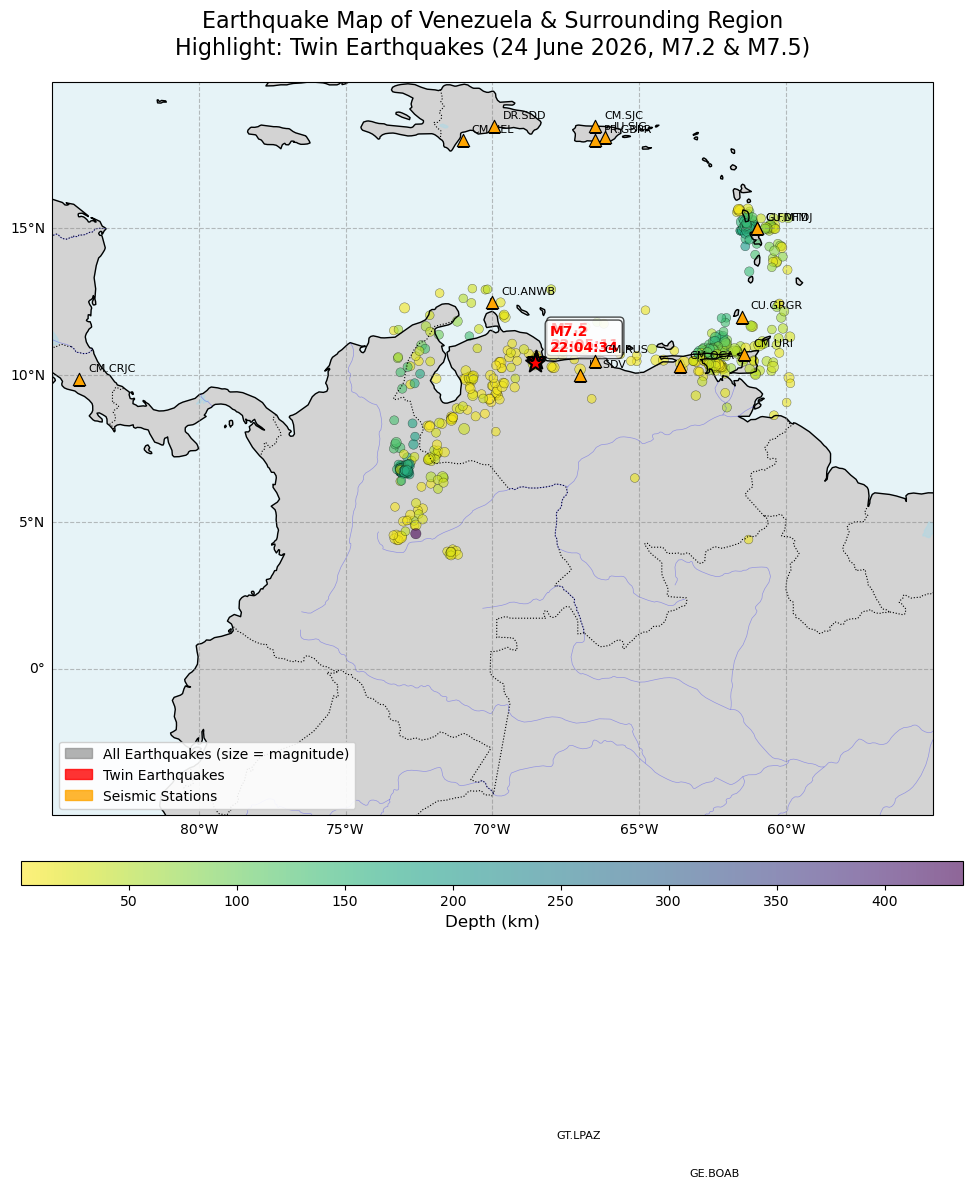

✨ Selesai.


In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VISUALISASI PETA GEMPA VENEZUELA DENGAN CARTOPY
- Menampilkan semua episenter dari katalog.
- Menyorot gempa kembar (24 Juni 2026, M7.2 & M7.5).
- Menampilkan stasiun seismik yang digunakan (dari JSON 3C).
"""

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.patches as mpatches

# =============================================
# 1. KONFIGURASI PATH
# =============================================
CATALOG_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/venezuela_earthquake_bench/query_venezuela.csv"
JSON_3C_PATH = "/Volumes/Extreme SSD/venezuela_data_earthquake/json_venezuela/extracted_data_3c_venez_v3.json"

OUTPUT_DIR = "/Volumes/Extreme SSD/venezuela_data_earthquake/visualisasi_venezuela"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_IMAGE = os.path.join(OUTPUT_DIR, "venezuela_earthquake_map.png")

# =============================================
# 2. KOORDINAT STASIUN (perkiraan)
# =============================================
# Jika stasiun tidak ada di sini, tambahkan sendiri.
# Sumber: IRIS atau pengetahuan umum.
STATION_COORDS = {
    "CM.CRJC": (9.865, -84.072),    # Costa Rica
    "CM.URI": (10.718, -61.411),    # Trinidad
    "CM.OCA": (10.300, -63.600),    # Venezuela (perkiraan)
    "DR.SDD": (18.480, -69.950),    # Dominican Republic
    "GE.BOAB": (-17.550, -63.600),  # Bolivia (jarak jauh)
    "G.FDFM": (15.000, -61.000),    # Martinique (perkiraan)
    "GT.LPAZ": (-16.280, -68.130),  # Bolivia
    "CM.HEL": (18.000, -71.000),     # Haiti (perkiraan)
    "CM.RUS": (10.500, -66.500),     # Venezuela (perkiraan)
    "CM.SJC": (18.500, -66.500),     # Puerto Rico
    "CU.ANWB": (12.500, -70.000),    # Aruba
    "CU.GRGR": (12.000, -61.500),    # Grenada
    "CU.MTDJ": (15.000, -61.000),    # Martinique
    "IU.SJG": (18.100, -66.150),     # Puerto Rico (Global)
    "IU.SDV": (10.000, -67.000),     # Venezuela
    "PR.GBPR": (18.000, -66.500),    # Puerto Rico
}

# =============================================
# 3. BACA DATA
# =============================================
print("📂 Membaca katalog...")
df = pd.read_csv(CATALOG_PATH)
df['time'] = pd.to_datetime(df['time'], utc=True)
print(f"✅ {len(df)} event di katalog.")

print("📂 Membaca JSON 3C...")
with open(JSON_3C_PATH, 'r') as f:
    data_3c = json.load(f)
print(f"✅ {len(data_3c)} entri di JSON 3C.")

# =============================================
# 4. EKSTRAK STASIUN DARI JSON 3C
# =============================================
stations = set()
for key in data_3c.keys():
    # Format key: NET_STA_YYYYMMDD_HHMMSS
    parts = key.split('_')
    if len(parts) >= 2:
        net = parts[0]
        sta = parts[1]
        stations.add(f"{net}.{sta}")

print(f"📍 {len(stations)} stasiun unik ditemukan di JSON.")
print("   Stasiun:", sorted(stations))

# =============================================
# 5. IDENTIFIKASI GEMPA KEMBAR
# =============================================
# Waktu gempa kembar: 2026-06-24 22:04:34 dan 22:05:11
twin_times = [
    pd.Timestamp("2026-06-24 22:04:34", tz='UTC'),
    pd.Timestamp("2026-06-24 22:05:11", tz='UTC')
]

twin_events = df[df['time'].isin(twin_times)]
if twin_events.empty:
    # Cari dengan toleransi 5 detik
    mask = False
    for t in twin_times:
        mask |= (df['time'] >= t - pd.Timedelta(seconds=5)) & (df['time'] <= t + pd.Timedelta(seconds=5))
    twin_events = df[mask]

print(f"🔍 Ditemukan {len(twin_events)} gempa kembar:")
print(twin_events[['time', 'mag', 'place', 'id']].to_string(index=False))

# =============================================
# 6. BUAT PETA
# =============================================
fig = plt.figure(figsize=(16, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

# --- Fitur peta ---
ax.add_feature(cfeature.LAND, color='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color='black')
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8, color='black')
ax.add_feature(cfeature.LAKES, color='lightblue', alpha=0.5)
ax.add_feature(cfeature.RIVERS, color='blue', linewidth=0.5, alpha=0.3)

# --- Gridlines ---
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# --- Atur batas wilayah (fokus pada Venezuela & Karibia) ---
ax.set_extent([-85, -55, -5, 20], crs=ccrs.PlateCarree())

# --- Plot semua episenter ---
# Skala: ukuran berdasarkan magnitudo, warna berdasarkan kedalaman
sc = ax.scatter(
    df['longitude'], df['latitude'],
    s=(df['mag'] - 3) * 20 + 10,  # ukuran proporsional
    c=df['depth'],
    cmap='viridis_r',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.3,
    transform=ccrs.PlateCarree(),
    label='All earthquakes'
)

# --- Sorot gempa kembar ---
if not twin_events.empty:
    ax.scatter(
        twin_events['longitude'], twin_events['latitude'],
        s=200,  # besar
        c='red',
        marker='*',
        edgecolors='black',
        linewidth=1.5,
        transform=ccrs.PlateCarree(),
        label='Twin Earthquakes (M7.2 & M7.5)',
        zorder=10
    )
    # Tambahkan anotasi
    for _, row in twin_events.iterrows():
        ax.text(
            row['longitude'] + 0.5, row['latitude'] + 0.3,
            f"M{row['mag']}\n{row['time'].strftime('%H:%M:%S')}",
            transform=ccrs.PlateCarree(),
            fontsize=10,
            fontweight='bold',
            color='red',
            ha='left',
            va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
        )

# --- Plot stasiun seismik ---
for sta in sorted(stations):
    if sta in STATION_COORDS:
        lat, lon = STATION_COORDS[sta]
        ax.scatter(
            lon, lat,
            marker='^',
            s=80,
            color='orange',
            edgecolors='black',
            linewidth=0.8,
            transform=ccrs.PlateCarree(),
            zorder=5
        )
        ax.text(
            lon + 0.3, lat + 0.2,
            sta,
            transform=ccrs.PlateCarree(),
            fontsize=8,
            color='black',
            ha='left',
            va='bottom'
        )
    else:
        print(f"⚠️ Koordinat untuk {sta} tidak tersedia. Tambahkan ke STATION_COORDS.")

# --- Colorbar untuk kedalaman ---
cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, aspect=40, shrink=0.6)
cbar.set_label('Depth (km)', fontsize=12)

# --- Legenda ---
legend_elements = [
    mpatches.Patch(label='All Earthquakes (size = magnitude)', color='gray', alpha=0.6),
    mpatches.Patch(label='Twin Earthquakes', color='red', alpha=0.8),
    mpatches.Patch(label='Seismic Stations', color='orange', alpha=0.8)
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.9)

# --- Judul ---
plt.title('Earthquake Map of Venezuela & Surrounding Region\nHighlight: Twin Earthquakes (24 June 2026, M7.2 & M7.5)', fontsize=16, pad=20)

# --- Simpan ---
plt.tight_layout()
plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches='tight')
print(f"✅ Peta tersimpan di: {OUTPUT_IMAGE}")

plt.show()
print("✨ Selesai.")